<a href="https://colab.research.google.com/github/AviramNisimyan/22961-Maman14/blob/main/Aviram_Nisimyan_206400178_Maman14_22961.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Aviram Nisimyan, 206400178, Maman 14 ,Deep Learning 22961**

# **Question 1:**

## **Importing:**

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

## **Questions 1.1 ּ+ 1.2:**

In [9]:
class SplitLinear(nn.Module):
  def __init__(self, M):
    super().__init__()

    if M % 2 != 0:
      raise ValueError("M must be even")

    self.M = M
    self.half = M // 2
    self.linear = nn.Linear(self.half, self.half)
    self.relu = nn.ReLU()

    # יש כמה דרכים לאתחל את הפרמטרים, ומאחר שפונקצית האקטיבציה היא relu נבחר ב-Kaiming Initialization
    nn.init.kaiming_uniform_(self.linear.weight, nonlinearity='relu')
    nn.init.zeros_(self.linear.bias)

def forward(self, x):
  x1, x2 = torch.tensor_split(X, 2, dim=1)
  z1 = self.linear(x1)
  z2 = self.linear(x2)
  z1 = self.relu(z1)
  z2 = self.relu(z2)
  y = torch.cat((z1, z2), dim=1)
  return y


## **Questions 1.3:**

In [4]:
torch.manual_seed(0) # כדי שתוכל לשחזר אחר כך את התוצאות כשתריץ
N = 3 # batch = 3
M = 6
layer = SplitLinear(M)
X = torch.randn(N, M)
print(f"1. Original Input (X) shape {X.shape}:\n{X}\n")
x1, x2 = torch.tensor_split(X, 2, dim=1)
print(f"2. Split X1 shape {x1.shape}:\n{x1}\n")
print(f"2. Split X2 shape {x2.shape}:\n{x2}\n")

z1 = layer.linear(x1)
z2 = layer.linear(x2)
print(f"3. linear(x1):\n{z1}\n")
print(f"3. linear(X2):\n{z2}\n")

z1 = layer.relu(z1)
z2 = layer.relu(z2)
print(f"4. relu(z1):\n{z1}\n")
print(f"4. relu(z2):\n{z2}\n")

y = torch.cat((z1, z2), dim=1)
print(f"5. y {y.shape}:\n{y}")

1. Original Input (X) shape torch.Size([3, 6]):
tensor([[-1.5551, -0.3414,  0.4412, -0.2159, -0.7425,  0.5627],
        [ 0.2596, -0.1740, -0.6787,  0.9383, -1.5867,  1.2032],
        [ 0.0845, -1.2001, -0.0048, -0.5181, -0.3067, -1.5810]])

2. Split X1 shape torch.Size([3, 3]):
tensor([[-1.5551, -0.3414,  0.4412],
        [ 0.2596, -0.1740, -0.6787],
        [ 0.0845, -1.2001, -0.0048]])

2. Split X2 shape torch.Size([3, 3]):
tensor([[-0.2159, -0.7425,  0.5627],
        [ 0.9383, -1.5867,  1.2032],
        [-0.5181, -0.3067, -1.5810]])

3. linear(x1):
tensor([[ 2.1636,  0.1020,  1.9278],
        [ 0.2078, -0.6596, -0.4904],
        [ 1.0126, -0.6706,  0.6556]], grad_fn=<AddmmBackward0>)

3. linear(X2):
tensor([[ 0.6591,  0.0510,  0.9533],
        [-0.4830,  0.1831,  0.6956],
        [ 1.9089, -1.5402, -0.1265]], grad_fn=<AddmmBackward0>)

4. relu(z1):
tensor([[2.1636, 0.1020, 1.9278],
        [0.2078, 0.0000, 0.0000],
        [1.0126, 0.0000, 0.6556]], grad_fn=<ReluBackward0>)

4. rel

## **Questions 1.4:**

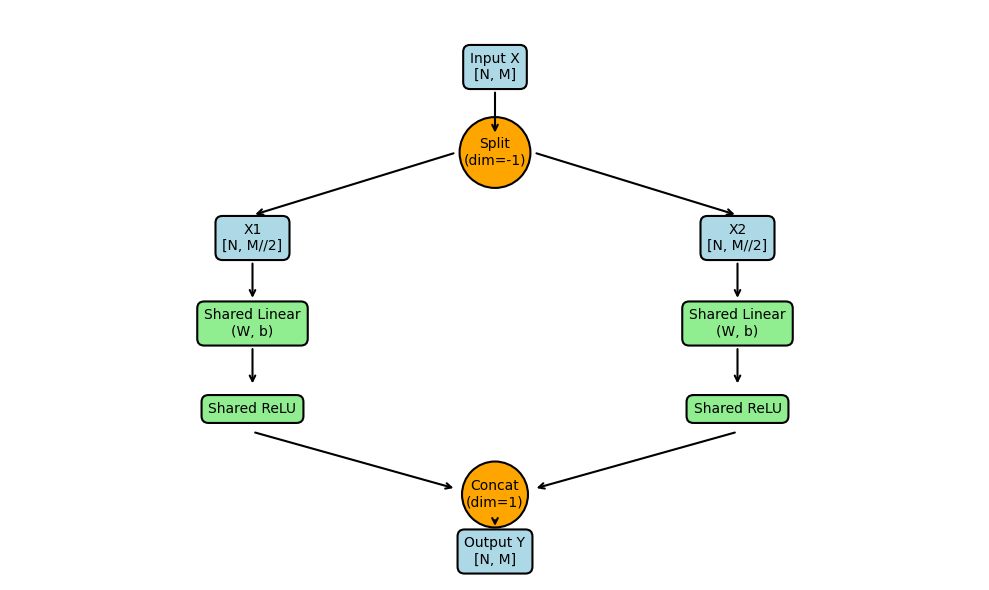

In [5]:
import matplotlib.pyplot as plt

def draw_architecture():
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.axis('off')

    # הגדרת סגנון הבלוקים
    box_style = dict(boxstyle="round,pad=0.5", fc="lightblue", ec="black", lw=1.5)
    shared_style = dict(boxstyle="round,pad=0.5", fc="lightgreen", ec="black", lw=1.5)
    op_style = dict(boxstyle="circle,pad=0.3", fc="orange", ec="black", lw=1.5)

    # ציור הבלוקים
    ax.text(0.5, 0.9, "Input X\n[N, M]", ha="center", va="center", bbox=box_style)
    ax.text(0.5, 0.75, "Split\n(dim=-1)", ha="center", va="center", bbox=op_style)

    # ענף שמאל (חצי ראשון)
    ax.text(0.25, 0.6, "X1\n[N, M//2]", ha="center", va="center", bbox=box_style)
    ax.text(0.25, 0.45, "Shared Linear\n(W, b)", ha="center", va="center", bbox=shared_style)
    ax.text(0.25, 0.3, "Shared ReLU", ha="center", va="center", bbox=shared_style)

    # ענף ימין (חצי שני)
    ax.text(0.75, 0.6, "X2\n[N, M//2]", ha="center", va="center", bbox=box_style)
    ax.text(0.75, 0.45, "Shared Linear\n(W, b)", ha="center", va="center", bbox=shared_style)
    ax.text(0.75, 0.3, "Shared ReLU", ha="center", va="center", bbox=shared_style)

    # איחוד
    ax.text(0.5, 0.15, "Concat\n(dim=1)", ha="center", va="center", bbox=op_style)
    ax.text(0.5, 0.05, "Output Y\n[N, M]", ha="center", va="center", bbox=box_style)

    # ציור חצים
    arrow_props = dict(arrowstyle="->", lw=1.5, color="black")
    ax.annotate("", xy=(0.5, 0.78), xytext=(0.5, 0.86), arrowprops=arrow_props)

    # חצים לענפים
    ax.annotate("", xy=(0.25, 0.64), xytext=(0.46, 0.75), arrowprops=arrow_props)
    ax.annotate("", xy=(0.75, 0.64), xytext=(0.54, 0.75), arrowprops=arrow_props)

    # חצי שמאל פנימיים
    ax.annotate("", xy=(0.25, 0.49), xytext=(0.25, 0.56), arrowprops=arrow_props)
    ax.annotate("", xy=(0.25, 0.34), xytext=(0.25, 0.41), arrowprops=arrow_props)
    ax.annotate("", xy=(0.46, 0.16), xytext=(0.25, 0.26), arrowprops=arrow_props)

    # חצי ימין פנימיים
    ax.annotate("", xy=(0.75, 0.49), xytext=(0.75, 0.56), arrowprops=arrow_props)
    ax.annotate("", xy=(0.75, 0.34), xytext=(0.75, 0.41), arrowprops=arrow_props)
    ax.annotate("", xy=(0.54, 0.16), xytext=(0.75, 0.26), arrowprops=arrow_props)

    ax.annotate("", xy=(0.5, 0.09), xytext=(0.5, 0.11), arrowprops=arrow_props)

    plt.tight_layout()
    plt.show()

draw_architecture()

## **Questions 1.5:**

In [10]:
M_test = 100  # נניח מספר מאפיינים שרירותי זוגי

custom_layer = SplitLinear(M_test)
regular_linear = nn.Linear(M_test, M_test)

params_custom = sum(p.numel() for p in custom_layer.parameters())
params_regular = sum(p.numel() for p in regular_linear.parameters())

print(f"עבור גודל מאפיינים M = {M_test}:")
print(f"מספר הפרמטרים בשכבת SplitLinear שלנו: {params_custom}")
print(f"מספר הפרמטרים בשכבה ליניארית רגילה: {params_regular}")
print(f"יחס החיסכון: שכבת הפיצול מכילה פי {params_regular / params_custom:.2f} פחות פרמטרים!")

# הוכחה מתמטית מודפסת בקוד:
# SplitLinear: (M/2)*(M/2) + M/2 = M^2 / 4 + M / 2
# Regular: M*M + M = M^2 + M
print(f"\nאימות אנליטי:")
print(f"חישוב לפי נוסחה לשכבה שלנו: {int((M_test**2)/4 + M_test/2)}")
print(f"חישוב לפי נוסחה לשכבה רגילה: {int(M_test**2 + M_test)}")

עבור גודל מאפיינים M = 100:
מספר הפרמטרים בשכבת SplitLinear שלנו: 2550
מספר הפרמטרים בשכבה ליניארית רגילה: 10100
יחס החיסכון: שכבת הפיצול מכילה פי 3.96 פחות פרמטרים!

אימות אנליטי:
חישוב לפי נוסחה לשכבה שלנו: 2550
חישוב לפי נוסחה לשכבה רגילה: 10100


## **Questions 1.6:**

## **Questions 1.7:**

# **Question 2:**

## **Importing:**

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

## **Questions 2.1 + 2.2 + 2.3:**

In [12]:
class DropNorm(nn.Module): # תוקן ל-Module עם M גדולה
    def __init__(self, num_features, eps=1e-5): # הוסף eps לבנאי
        super().__init__()
        self.num_features = num_features
        self.eps = eps # הגדרת המשתנה

        if num_features % 2 != 0:
            raise ValueError("num_features must be even")

        self.gamma = nn.Parameter(torch.ones(num_features))
        self.beta = nn.Parameter(torch.zeros(num_features))

    def forward(self, x): # שונה ל-x קטנה לאורך כל הקוד
        original_shape = x.shape # תוקנה שגיאת הכתיב
        N = original_shape[0] # Batch Size
        flat_input = x.reshape(N, -1) # [N, F]
        input_features = flat_input.shape[1]

        if input_features != self.num_features:
            raise ValueError(f"גודל המאפיינים בקלט ({input_features}) אינו תואם להגדרת השכבה ({self.num_features}).")

        # ההזחה (Indentation) תוקנה - הבלוק הזה באותו קו של ה-if הקודם
        if self.training:
            # --- מצב אימון ---

            # 2. בחירת חצי מהמאפיינים באקראי והכנת מסכה
            shuffled_indices = torch.randperm(input_features, device=x.device)
            active_indices = shuffled_indices[: input_features // 2]

            dropout_mask = torch.zeros(input_features, device=x.device, dtype=x.dtype)
            dropout_mask[active_indices] = 1.0

            # 3. חישוב תוחלת ושונות רק על המאפיינים הפעילים
            active_features = flat_input[:, active_indices]
            sample_mean = active_features.mean(dim=1, keepdim=True)
            sample_variance = active_features.var(dim=1, keepdim=True, unbiased=False)

            # 4. נורמליזציה של כל הטנזור (הערכים המאופסים יטופלו מיד לאחר מכן)
            normalized_input = (flat_input - sample_mean) / torch.sqrt(sample_variance + self.eps)

            # 5. הכפלה בפרמטרים הנלמדים והחלת המסכה
            output = self.gamma * normalized_input + self.beta
            output = output * dropout_mask

        else:
            # --- מצב חיזוי ---
            # ללא איפוס; מנרמלים לפי כל המאפיינים
            sample_mean = flat_input.mean(dim=1, keepdim=True)
            sample_variance = flat_input.var(dim=1, keepdim=True, unbiased=False)

            normalized_input = (flat_input - sample_mean) / torch.sqrt(sample_variance + self.eps)
            output = self.gamma * normalized_input + self.beta

        # החזרת הטנזור למימדיו המקוריים
        return output.reshape(original_shape)

## **Question 2.4:**

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

batch_size = 64
learning_rate = 0.001
num_epochs = 10

# ==========================================
# 2. הכנת הנתונים (Fashion-MNIST)
# ==========================================
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, transform=transform, download=True
)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, transform=transform, download=True
)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

# ==========================================
# 3. הגדרת המודל (עם שכבות מובנות)
# ==========================================
class StandardNet(nn.Module):
    def __init__(self):
        super().__init__()
        # 28*28 = 784 מאפיינים (גודל תמונה ב-Fashion MNIST)
        self.fc1 = nn.Linear(28 * 28, 256)

        # שימוש בשכבות המובנות של PyTorch כפי שנדרש
        self.bn1 = nn.BatchNorm1d(256)
        self.drop = nn.Dropout(0.5)

        self.fc2 = nn.Linear(256, 10) # 10 מחלקות של פריטי לבוש

    def forward(self, x):
        # השטחת התמונה לוקטור דו-מימדי [Batch, 784]
        flat_input = x.reshape(x.shape[0], -1)

        # מעבר דרך השכבה הליניארית, נורמליזציה, ואקטיבציה
        hidden = torch.relu(self.bn1(self.fc1(flat_input)))

        # הפעלת ה-Dropout המובנה
        dropped_hidden = self.drop(hidden)

        # שכבת הפלט (ללא אקטיבציה כי פונקציית המחיר CrossEntropyLoss מבצעת Softmax)
        output = self.fc2(dropped_hidden)
        return output

# יצירת מופע של המודל והעברתו ל-GPU/CPU
model = StandardNet().to(device)

# ==========================================
# 4. פונקציית מחיר ואופטימיזטור
# ==========================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# ==========================================
# 5. תהליך האימון (Training Loop)
# ==========================================
print("Starting training...")

for epoch in range(num_epochs):
    model.train() # מעבר למצב אימון (מפעיל Dropout ו-BatchNorm)
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        # העברת הנתונים למאיץ הגרפי
        images = images.to(device)
        labels = labels.to(device)

        # איפוס גרדיאנטים
        optimizer.zero_grad()

        # מעבר קדימה (Forward Pass)
        outputs = model(images)
        loss = criterion(outputs, labels)

        # מעבר אחורה (Backward Pass) ועדכון משקלים
        loss.backward()
        optimizer.step()

        # חישוב מדדי אימון
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct_train / total_train

    # --- שלב ההערכה (Validation/Testing) בסוף כל Epoch ---
    model.eval() # מעבר למצב חיזוי (מכבה Dropout, משתמש בסטטיסטיקות עולמיות ב-BatchNorm)
    correct_test = 0
    total_test = 0

    with torch.no_grad(): # אין צורך בחישוב גרדיאנטים בזמן בדיקה
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    test_acc = 100 * correct_test / total_test

    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {epoch_loss:.4f} | "
          f"Train Acc: {epoch_acc:.2f}% | "
          f"Test Acc: {test_acc:.2f}%")

print("Training finished.")

Using device: cpu


100%|██████████| 26.4M/26.4M [00:01<00:00, 17.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 272kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.09MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 19.0MB/s]


Starting training...
Epoch [1/10] | Train Loss: 0.5192 | Train Acc: 81.65% | Test Acc: 84.80%
Epoch [2/10] | Train Loss: 0.4138 | Train Acc: 85.06% | Test Acc: 86.05%
Epoch [3/10] | Train Loss: 0.3827 | Train Acc: 86.14% | Test Acc: 85.70%
Epoch [4/10] | Train Loss: 0.3670 | Train Acc: 86.68% | Test Acc: 87.24%
Epoch [5/10] | Train Loss: 0.3524 | Train Acc: 87.25% | Test Acc: 87.20%
Epoch [6/10] | Train Loss: 0.3434 | Train Acc: 87.44% | Test Acc: 86.81%
Epoch [7/10] | Train Loss: 0.3324 | Train Acc: 87.82% | Test Acc: 87.43%
Epoch [8/10] | Train Loss: 0.3231 | Train Acc: 88.27% | Test Acc: 88.04%
Epoch [9/10] | Train Loss: 0.3141 | Train Acc: 88.39% | Test Acc: 88.36%
Epoch [10/10] | Train Loss: 0.3070 | Train Acc: 88.52% | Test Acc: 88.15%
Training finished.


## **Question 2.5:**

In [ ]:
# ==========================================
# הגדרת המודל עם השכבה המותאמית אישית (סעיף ה')
# ==========================================
class CustomNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, 256)

        # שימוש בשכבת ה-DropNorm שיצרנו במקום BatchNorm + Dropout
        self.dropnorm = DropNorm(num_features=256)

        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        flat_input = x.reshape(x.shape[0], -1)

        # העברת המידע דרך השכבה הליניארית, ואז דרך ה-DropNorm שלנו
        hidden = self.dropnorm(self.fc1(flat_input))

        # אקטיבציה לאחר הנורמליזציה
        activated_hidden = torch.relu(hidden)

        output = self.fc2(activated_hidden)
        return output

# יצירת המודל והעברתו ל-GPU
custom_model = CustomNet().to(device)

# הגדרת אופטימיזטור חדש עבור המודל הזה
custom_optimizer = optim.Adam(custom_model.parameters(), lr=learning_rate)

# הערה: כדי לאמן אותו, פשוט מעבירים את custom_model ו-custom_optimizer
# לתוך לולאת האימון (for epoch in range...) שנכתבה בסעיף ד'.